# Ranking Comparativo de Modelos de Machine Learning

Este notebook gera dinamicamente um ranking de todos os modelos treinados, agrupados por:
- **Tipo de problema**: Regressão vs Classificação
- **Janela de tempo**: 3, 7, 15 e 30 dias

Os dados são carregados automaticamente a partir dos CSVs de métricas gerados no treinamento.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## 1. Coleta Dinâmica dos CSVs de Métricas

In [2]:
MODELS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'models')

# Mapeamento de modelos para tipo de problema
MODELOS_REGRESSAO = {'regressao_linear', 'regressao_linear_rede_neural'}
MODELOS_CLASSIFICACAO = {'regressao_logistica', 'random_forest', 'xgboost', 'classificacao_rede_neural'}

# Nomes amigáveis para exibição
NOMES_MODELOS = {
    'regressao_linear': 'Regressão Linear',
    'regressao_linear_rede_neural': 'Rede Neural (Regressão)',
    'regressao_logistica': 'Regressão Logística',
    'random_forest': 'Random Forest',
    'xgboost': 'XGBoost',
    'classificacao_rede_neural': 'Rede Neural (Classificação)',
}

NOMES_DATASETS = {
    'dataset_base': 'Base',
    'dataset_dummy': 'Dummy',
    'dataset_indicadores': 'Indicadores',
    'dataset_janelas': 'Janelas',
}

HORIZONTES = ['3 dias', '7 dias', '15 dias', '30 dias']

print(f'Diretório dos modelos: {MODELS_DIR}')
print(f'Existe: {os.path.exists(MODELS_DIR)}')

Diretório dos modelos: /home/garbielterrasolangroup/Documents/Repositorios/TCC/Analise-comparativa-de-modelos-de-machine-learning---Agro-Brasil---TCC/models
Existe: True


In [3]:
def coletar_metricas(models_dir):
    """
    Varre dinamicamente o diretório de modelos e coleta todos os CSVs de métricas.
    Retorna um DataFrame consolidado com colunas extras:
    - modelo, dataset, ticker, tipo (regressao/classificacao)

    Mantém separadas as métricas de teste e OOF.
    """
    todos_registros = []

    csv_files = glob.glob(os.path.join(models_dir, '**', '*.csv'), recursive=True)
    print(f'Total de arquivos CSV encontrados: {len(csv_files)}')

    def normalizar_colunas(df, tipo):
        """Normaliza nomes de colunas sem misturar métricas de teste com OOF."""
        df.columns = [c.replace('R²', 'R2').strip() for c in df.columns]

        if tipo == 'regressao':
            mapa = {
                'CV MAE': 'CV_MAE',
                'OOF R2': 'OOF_R2',
                'OOF MAE': 'OOF_MAE',
                'Test R2': 'Test_R2',
                'Test MAE': 'Test_MAE',
                'Test RMSE': 'Test_RMSE',
            }
        else:
            mapa = {
                'CV F1': 'CV_F1_Best',
                'Threshold Otimo (PR)': 'Threshold_Otimo',
                'OOF F1 no Threshold': 'OOF_F1_Threshold',
                'Test Accuracy': 'Teste_Accuracy',
                'Test F1-Score': 'Teste_F1_Weighted',
                'Test Precision': 'Teste_Precision',
                'Test Recall': 'Teste_Recall',
                'Test AUC-ROC': 'Teste_AUC_ROC',
                'Test F1 Classe Alta': 'Teste_F1_Classe_Alta',
            }

        return df.rename(columns=mapa)

    for csv_path in csv_files:
        rel_path = os.path.relpath(csv_path, models_dir)
        parts = rel_path.split(os.sep)

        if len(parts) < 3:
            continue

        modelo = parts[0]
        dataset = parts[1]

        filename = os.path.basename(csv_path)
        ticker = None
        for t in ['agro3', 'slce3', 'soja3']:
            if t in filename.lower():
                ticker = t.upper()
                break

        if ticker is None:
            continue

        if modelo in MODELOS_REGRESSAO:
            tipo = 'regressao'
        elif modelo in MODELOS_CLASSIFICACAO:
            tipo = 'classificacao'
        else:
            continue

        try:
            df = pd.read_csv(csv_path)
            df = normalizar_colunas(df, tipo)

            df['modelo'] = modelo
            df['modelo_nome'] = NOMES_MODELOS.get(modelo, modelo)
            df['dataset'] = dataset
            df['dataset_nome'] = NOMES_DATASETS.get(dataset, dataset)
            df['ticker'] = ticker
            df['tipo'] = tipo

            for _, row in df.iterrows():
                todos_registros.append(row.to_dict())
        except Exception as e:
            print(f'Erro ao ler {csv_path}: {e}')

    if not todos_registros:
        print('Nenhum registro encontrado!')
        return pd.DataFrame()

    df_all = pd.DataFrame(todos_registros)
    print(f'Total de registros coletados: {len(df_all)}')
    print(f'Modelos encontrados: {sorted(df_all["modelo"].unique())}')
    print(f'Datasets encontrados: {sorted(df_all["dataset"].unique())}')
    print(f'Tickers encontrados: {sorted(df_all["ticker"].unique())}')
    print(f'Tipos: {sorted(df_all["tipo"].unique())}')
    return df_all

df_all = coletar_metricas(MODELS_DIR)
df_all.head()

Total de arquivos CSV encontrados: 74
Total de registros coletados: 288
Modelos encontrados: ['classificacao_rede_neural', 'random_forest', 'regressao_linear', 'regressao_linear_rede_neural', 'regressao_logistica', 'xgboost']
Datasets encontrados: ['dataset_base', 'dataset_dummy', 'dataset_indicadores', 'dataset_janelas']
Tickers encontrados: ['AGRO3', 'SLCE3', 'SOJA3']
Tipos: ['classificacao', 'regressao']


,Horizonte,CV_F1_Best,Threshold_Otimo,OOF_F1_Threshold,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,modelo,modelo_nome,dataset,dataset_nome,ticker,tipo,CV_MAE,OOF_R2,OOF_MAE,Test_R2,Test_MAE,Test_RMSE
0,3 dias,0.6905,0.3517,0.7158,0.6300,0.6795,0.6300,0.6007,0.7098,0.7535,random_forest,Random Forest,dataset_indicadores,Indicadores,SLCE3,classificacao,NaN,NaN,NaN,NaN,NaN,NaN
1,7 dias,0.8114,0.4638,0.8248,0.7829,0.7958,0.7829,0.7787,0.8136,0.8883,random_forest,Random Forest,dataset_indicadores,Indicadores,SLCE3,classificacao,NaN,NaN,NaN,NaN,NaN,NaN
2,15 dias,0.8693,0.4618,0.8753,0.8379,0.8422,0.8379,0.8365,0.8571,0.9372,random_forest,Random Forest,dataset_indicadores,Indicadores,SLCE3,classificacao,NaN,NaN,NaN,NaN,NaN,NaN
3,30 dias,0.9052,0.4781,0.9067,0.9205,0.9206,0.9205,0.9204,0.9282,0.9671,random_forest,Random Forest,dataset_indicadores,Indicadores,SLCE3,classificacao,NaN,NaN,NaN,NaN,NaN,NaN
4,3 dias,0.6872,0.3874,0.7179,0.6864,0.7258,0.6864,0.6775,0.7254,0.7855,random_forest,Random Forest,dataset_indicadores,Indicadores,SOJA3,classificacao,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Separação por Tipo de Problema

In [4]:
df_regressao = df_all[df_all['tipo'] == 'regressao'].copy()
df_classificacao = df_all[df_all['tipo'] == 'classificacao'].copy()

print(f'Registros de Regressão: {len(df_regressao)}')
print(f'Registros de Classificação: {len(df_classificacao)}')

Registros de Regressão: 96
Registros de Classificação: 192


---
## 3. Rankings de REGRESSÃO (por Janela de Tempo)

Métricas de regressão:
- **R²** (quanto maior, melhor)
- **MAE** (quanto menor, melhor)
- **RMSE** (quanto menor, melhor)

O ranking principal é ordenado por **R² decrescente**.

In [5]:
def ranking_regressao(df, horizonte):
    """
    Gera ranking de modelos de regressão para um horizonte específico.
    Ordenado por Test_R2 (decrescente), depois Test_MAE (crescente).
    """
    df_h = df[df['Horizonte'] == horizonte].copy()
    if df_h.empty:
        print(f'  Sem dados para horizonte: {horizonte}')
        return pd.DataFrame()

    df_h = df_h.sort_values(['Test_R2', 'Test_MAE'], ascending=[False, True]).reset_index(drop=True)
    df_h.index = df_h.index + 1
    df_h.index.name = 'Ranking'

    cols = ['modelo_nome', 'dataset_nome', 'ticker', 'Test_R2', 'Test_MAE', 'Test_RMSE', 'OOF_R2', 'OOF_MAE', 'CV_MAE']
    return df_h[cols].rename(columns={
        'modelo_nome': 'Modelo',
        'dataset_nome': 'Dataset',
        'ticker': 'Ticker',
    })


for horizonte in HORIZONTES:
    print(f'\n{"="*80}')
    print(f'  RANKING REGRESSÃO — {horizonte.upper()}')
    print(f'{"="*80}')
    ranking = ranking_regressao(df_regressao, horizonte)
    if not ranking.empty:
        display(ranking)


  RANKING REGRESSÃO — 3 DIAS


,Modelo,Dataset,Ticker,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Ranking,,,,,,,,,
1,Rede Neural (Regressão),Dummy,SLCE3,0.9942,0.3027,0.4089,0.9914,0.3513,0.3513
2,Rede Neural (Regressão),Dummy,AGRO3,0.9937,0.3386,0.4784,0.9919,0.3826,0.3826
3,Rede Neural (Regressão),Base,AGRO3,0.9936,0.3420,0.4816,0.9919,0.3808,0.3808
4,Rede Neural (Regressão),Indicadores,SLCE3,0.9936,0.3089,0.4253,0.9915,0.3434,0.3434
5,Rede Neural (Regressão),Base,SLCE3,0.9931,0.3335,0.4478,0.9912,0.3619,0.3619
6,Rede Neural (Regressão),Indicadores,AGRO3,0.9925,0.3704,0.5157,0.9929,0.3567,0.3567
7,Regressão Linear,Indicadores,SLCE3,0.9914,0.3522,0.4915,0.9902,0.3743,0.3744
8,Regressão Linear,Dummy,AGRO3,0.9910,0.3794,0.5711,0.9904,0.4047,0.4047
9,Regressão Linear,Base,AGRO3,0.9908,0.3812,0.5782,0.9903,0.4073,0.4073



  RANKING REGRESSÃO — 7 DIAS


,Modelo,Dataset,Ticker,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Ranking,,,,,,,,,
1,Rede Neural (Regressão),Indicadores,SLCE3,0.9937,0.3120,0.4211,0.9918,0.3453,0.3453
2,Rede Neural (Regressão),Indicadores,AGRO3,0.9932,0.3552,0.4920,0.9915,0.3848,0.3848
3,Rede Neural (Regressão),Base,SLCE3,0.9929,0.3242,0.4517,0.9876,0.4136,0.4136
4,Rede Neural (Regressão),Dummy,AGRO3,0.9914,0.3897,0.5558,0.9897,0.4291,0.4290
5,Rede Neural (Regressão),Base,AGRO3,0.9911,0.3965,0.5643,0.9887,0.4519,0.4519
6,Rede Neural (Regressão),Dummy,SLCE3,0.9911,0.3518,0.5060,0.9891,0.4018,0.4018
7,Rede Neural (Regressão),Janelas,SLCE3,0.9902,0.3666,0.5239,0.9881,0.4170,0.4170
8,Rede Neural (Regressão),Janelas,AGRO3,0.9898,0.4312,0.6086,0.9867,0.4721,0.4721
9,Regressão Linear,Base,SLCE3,0.9821,0.5280,0.7185,0.9794,0.5683,0.5683



  RANKING REGRESSÃO — 15 DIAS


,Modelo,Dataset,Ticker,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Ranking,,,,,,,,,
1,Rede Neural (Regressão),Indicadores,AGRO3,0.9938,0.3392,0.4682,0.9906,0.4105,0.4105
2,Rede Neural (Regressão),Indicadores,SLCE3,0.9931,0.3213,0.4364,0.9908,0.3662,0.3662
3,Rede Neural (Regressão),Janelas,SLCE3,0.9880,0.4194,0.5747,0.9842,0.4646,0.4646
4,Rede Neural (Regressão),Base,SLCE3,0.9879,0.4166,0.5865,0.9817,0.5161,0.5161
5,Rede Neural (Regressão),Base,AGRO3,0.9874,0.4509,0.6703,0.9828,0.5248,0.5248
6,Rede Neural (Regressão),Dummy,AGRO3,0.9872,0.4449,0.6757,0.9884,0.4578,0.4578
7,Rede Neural (Regressão),Dummy,SLCE3,0.9866,0.4461,0.6190,0.9851,0.4579,0.4579
8,Rede Neural (Regressão),Janelas,AGRO3,0.9856,0.5096,0.7191,0.9811,0.5569,0.5569
9,Regressão Linear,Dummy,SLCE3,0.9693,0.6951,0.9351,0.9606,0.7932,0.7932



  RANKING REGRESSÃO — 30 DIAS


,Modelo,Dataset,Ticker,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Ranking,,,,,,,,,
1,Rede Neural (Regressão),Indicadores,SLCE3,0.9921,0.3592,0.4654,0.9896,0.3776,0.3776
2,Rede Neural (Regressão),Indicadores,AGRO3,0.9914,0.3911,0.5504,0.9887,0.4231,0.4232
3,Rede Neural (Regressão),Dummy,SLCE3,0.9894,0.3930,0.5440,0.9835,0.4712,0.4712
4,Rede Neural (Regressão),Base,SLCE3,0.9860,0.4612,0.6269,0.9776,0.5334,0.5333
5,Rede Neural (Regressão),Janelas,SLCE3,0.9805,0.5197,0.7247,0.9803,0.5274,0.5274
6,Rede Neural (Regressão),Dummy,AGRO3,0.9803,0.5142,0.8542,0.9763,0.5599,0.5598
7,Rede Neural (Regressão),Janelas,AGRO3,0.9745,0.6328,0.9662,0.9693,0.6600,0.6600
8,Rede Neural (Regressão),Base,AGRO3,0.9694,0.6764,1.0634,0.9667,0.6620,0.6619
9,Rede Neural (Regressão),Indicadores,SOJA3,0.9627,0.3227,0.4002,0.9510,0.3387,0.3387


---
## 4. Rankings de CLASSIFICAÇÃO (por Janela de Tempo)

Métricas de classificação:
- **Accuracy, Precision, Recall, F1-Score, AUC-ROC** (quanto maior, melhor)

O ranking principal é ordenado por **F1-Score decrescente**.

In [6]:
def ranking_classificacao(df, horizonte):
    """
    Gera ranking de modelos de classificação para um horizonte específico.
    Ordenado por Teste_F1_Weighted (decrescente), depois Teste_AUC_ROC (decrescente).
    """
    df_h = df[df['Horizonte'] == horizonte].copy()
    if df_h.empty:
        print(f'  Sem dados para horizonte: {horizonte}')
        return pd.DataFrame()

    df_h = df_h.sort_values(['Teste_F1_Weighted', 'Teste_AUC_ROC'], ascending=[False, False]).reset_index(drop=True)
    df_h.index = df_h.index + 1
    df_h.index.name = 'Ranking'

    cols = ['modelo_nome', 'dataset_nome', 'ticker', 'Teste_Accuracy', 'Teste_Precision', 'Teste_Recall', 'Teste_F1_Weighted', 'Teste_AUC_ROC', 'CV_F1_Best', 'OOF_F1_Threshold']
    return df_h[cols].rename(columns={
        'modelo_nome': 'Modelo',
        'dataset_nome': 'Dataset',
        'ticker': 'Ticker',
    })


for horizonte in HORIZONTES:
    print(f'\n{"="*80}')
    print(f'  RANKING CLASSIFICAÇÃO — {horizonte.upper()}')
    print(f'{"="*80}')
    ranking = ranking_classificacao(df_classificacao, horizonte)
    if not ranking.empty:
        display(ranking)


  RANKING CLASSIFICAÇÃO — 3 DIAS


,Modelo,Dataset,Ticker,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,XGBoost,Indicadores,SOJA3,0.6864,NaN,NaN,0.6864,0.7746,0.6790,0.6894
2,XGBoost,Indicadores,AGRO3,0.7003,NaN,NaN,0.6809,0.7725,0.6890,0.7234
3,Random Forest,Indicadores,SOJA3,0.6864,0.7258,0.6864,0.6775,0.7855,0.6872,0.7179
4,XGBoost,Base,SOJA3,0.6590,NaN,NaN,0.6566,0.7330,0.6654,0.6922
5,Random Forest,Indicadores,AGRO3,0.6728,0.7163,0.6728,0.6498,0.7617,0.6987,0.7342
6,Random Forest,Janelas,SLCE3,0.6424,0.6567,0.6424,0.6326,0.7017,0.6604,0.6992
7,Random Forest,Dummy,AGRO3,0.6284,0.6362,0.6284,0.6177,0.6907,0.6798,0.7158
8,Random Forest,Janelas,AGRO3,0.6364,0.6716,0.6364,0.6097,0.7026,0.6747,0.7148
9,XGBoost,Janelas,SLCE3,0.6212,NaN,NaN,0.6078,0.7025,0.6455,0.6919



  RANKING CLASSIFICAÇÃO — 7 DIAS


,Modelo,Dataset,Ticker,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,Random Forest,Indicadores,AGRO3,0.8073,0.8075,0.8073,0.8074,0.8849,0.8235,0.8253
2,XGBoost,Indicadores,SLCE3,0.7982,NaN,NaN,0.7948,0.8869,0.8198,0.8341
3,Random Forest,Indicadores,SOJA3,0.7929,0.8002,0.7929,0.7918,0.8618,0.7688,0.7793
4,XGBoost,Indicadores,AGRO3,0.7920,NaN,NaN,0.7909,0.8663,0.8076,0.8108
5,Random Forest,Janelas,AGRO3,0.7939,0.8080,0.7939,0.7882,0.8852,0.7683,0.7846
6,XGBoost,Indicadores,SOJA3,0.7870,NaN,NaN,0.7869,0.8714,0.7556,0.7827
7,Random Forest,Dummy,AGRO3,0.7885,0.8080,0.7885,0.7813,0.8683,0.7827,0.7917
8,XGBoost,Base,AGRO3,0.7825,NaN,NaN,0.7801,0.8468,0.7770,0.7787
9,Random Forest,Base,SLCE3,0.7825,0.7888,0.7825,0.7798,0.8790,0.7930,0.8088



  RANKING CLASSIFICAÇÃO — 15 DIAS


,Modelo,Dataset,Ticker,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,Random Forest,Indicadores,AGRO3,0.8777,0.8787,0.8777,0.8779,0.9393,0.8875,0.8901
2,XGBoost,Base,SOJA3,0.8555,NaN,NaN,0.8556,0.9184,0.8161,0.8253
3,XGBoost,Indicadores,AGRO3,0.8532,NaN,NaN,0.8523,0.9244,0.8723,0.8771
4,XGBoost,Dummy,SOJA3,0.8497,NaN,NaN,0.8498,0.9299,0.8160,0.8395
5,Random Forest,Janelas,AGRO3,0.8485,0.8489,0.8485,0.8476,0.9199,0.8412,0.8436
6,Random Forest,Dummy,AGRO3,0.8429,0.8429,0.8429,0.8421,0.9234,0.8522,0.8534
7,XGBoost,Janelas,SOJA3,0.8421,NaN,NaN,0.8421,0.9346,0.8184,0.8228
8,XGBoost,Indicadores,SLCE3,0.8410,NaN,NaN,0.8395,0.9312,0.8659,0.8703
9,Random Forest,Dummy,SLCE3,0.8399,0.8449,0.8399,0.8382,0.9295,0.8439,0.8463



  RANKING CLASSIFICAÇÃO — 30 DIAS


,Modelo,Dataset,Ticker,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,Random Forest,Indicadores,SLCE3,0.9205,0.9206,0.9205,0.9204,0.9671,0.9052,0.9067
2,XGBoost,Indicadores,AGRO3,0.9174,NaN,NaN,0.9169,0.9675,0.9076,0.9093
3,XGBoost,Indicadores,SLCE3,0.9144,NaN,NaN,0.9144,0.9688,0.9066,0.9083
4,Random Forest,Indicadores,AGRO3,0.9052,0.9055,0.9052,0.9046,0.9620,0.9068,0.9068
5,Random Forest,Dummy,SOJA3,0.9017,0.9126,0.9017,0.9021,0.9795,0.8655,0.8711
6,XGBoost,Janelas,SOJA3,0.9006,NaN,NaN,0.9007,0.9732,0.8475,0.8499
7,Random Forest,Dummy,SLCE3,0.9003,0.9002,0.9003,0.9002,0.9553,0.8855,0.8928
8,XGBoost,Dummy,SOJA3,0.8960,NaN,NaN,0.8963,0.9703,0.8481,0.8623
9,Random Forest,Janelas,SOJA3,0.8947,0.8976,0.8947,0.8951,0.9610,0.8422,0.8571


---
## 5. Ranking Médio por Modelo (agregado por dataset e ticker)

Média das métricas de cada modelo em todos os datasets e tickers, segmentado por janela de tempo.

In [7]:
print('=' * 80)
print('  RANKING MÉDIO — REGRESSÃO (média por modelo e horizonte)')
print('=' * 80)

for horizonte in HORIZONTES:
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        continue

    media = (
        df_h.groupby('modelo_nome')[[
            'Test_R2', 'Test_MAE', 'Test_RMSE',
            'OOF_R2', 'OOF_MAE', 'CV_MAE'
        ]]
        .mean()
        .sort_values('Test_R2', ascending=False)
    )
    media.index.name = 'Modelo'

    print(f'\n--- {horizonte} ---')
    display(media)

  RANKING MÉDIO — REGRESSÃO (média por modelo e horizonte)

--- 3 dias ---


,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Modelo,,,,,,
Rede Neural (Regressão),0.9785,0.3411,0.4613,0.9737,0.3712,0.3712
Regressão Linear,0.9756,0.3639,0.5140,0.9712,0.3866,0.3866



--- 7 dias ---


,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Modelo,,,,,,
Rede Neural (Regressão),0.9725,0.3671,0.5067,0.9662,0.4156,0.4156
Regressão Linear,0.9398,0.5593,0.7701,0.9421,0.5807,0.5807



--- 15 dias ---


,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Modelo,,,,,,
Rede Neural (Regressão),0.9610,0.4258,0.5956,0.9609,0.4575,0.4574
Regressão Linear,0.8897,0.7738,1.0493,0.8869,0.8298,0.8298



--- 30 dias ---


,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Modelo,,,,,,
Rede Neural (Regressão),0.9710,0.4542,0.6413,0.9592,0.4909,0.4909
Regressão Linear,0.8274,1.0962,1.4191,0.8178,1.1155,1.1155


In [8]:
print('=' * 80)
print('  RANKING MÉDIO — CLASSIFICAÇÃO (média por modelo e horizonte)')
print('=' * 80)

for horizonte in HORIZONTES:
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        continue

    media = (
        df_h.groupby('modelo_nome')[[
            'Teste_Accuracy', 'Teste_Precision', 'Teste_Recall',
            'Teste_F1_Weighted', 'Teste_F1_Classe_Alta', 'Teste_AUC_ROC',
            'CV_F1_Best', 'OOF_F1_Threshold'
        ]]
        .mean()
        .sort_values('Teste_F1_Weighted', ascending=False)
    )
    media.index.name = 'Modelo'

    print(f'\n--- {horizonte} ---')
    display(media)

  RANKING MÉDIO — CLASSIFICAÇÃO (média por modelo e horizonte)

--- 3 dias ---


,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Modelo,,,,,,,,
Random Forest,0.6178,0.6602,0.6178,0.5899,0.6937,0.7156,0.6748,0.7089
XGBoost,0.6054,NaN,NaN,0.5682,0.6865,0.6838,0.6708,0.6993
Rede Neural (Classificação),0.4881,NaN,NaN,0.3706,0.3225,0.4675,0.6634,0.6668
Regressão Logística,0.5095,NaN,NaN,0.3639,0.6667,0.5624,0.5877,0.6698



--- 7 dias ---


,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Modelo,,,,,,,,
Random Forest,0.7590,0.7726,0.7590,0.7542,0.7907,0.8504,0.7826,0.7965
XGBoost,0.7473,NaN,NaN,0.7403,0.7821,0.8347,0.7737,0.7870
Regressão Logística,0.5402,NaN,NaN,0.4068,0.6914,0.6165,0.6280,0.6913
Rede Neural (Classificação),0.4946,NaN,NaN,0.3636,0.3028,0.4882,0.6866,0.6881



--- 15 dias ---


,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Modelo,,,,,,,,
Random Forest,0.8312,0.8358,0.8312,0.8301,0.8458,0.9254,0.8488,0.8533
XGBoost,0.8308,NaN,NaN,0.8289,0.8485,0.9158,0.8410,0.8490
Rede Neural (Classificação),0.6696,NaN,NaN,0.6515,0.7242,0.7601,0.7181,0.7416
Regressão Logística,0.5966,NaN,NaN,0.5298,0.7094,0.6639,0.6525,0.7075



--- 30 dias ---


,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Modelo,,,,,,,,
Random Forest,0.8900,0.8923,0.8900,0.8899,0.8972,0.9567,0.8808,0.8846
XGBoost,0.8863,NaN,NaN,0.8863,0.8936,0.9548,0.8772,0.8823
Rede Neural (Classificação),0.7920,NaN,NaN,0.7892,0.8158,0.8884,0.7993,0.8092
Regressão Logística,0.6388,NaN,NaN,0.5881,0.7289,0.7305,0.7011,0.7309


---
## 6. Visualizações Comparativas

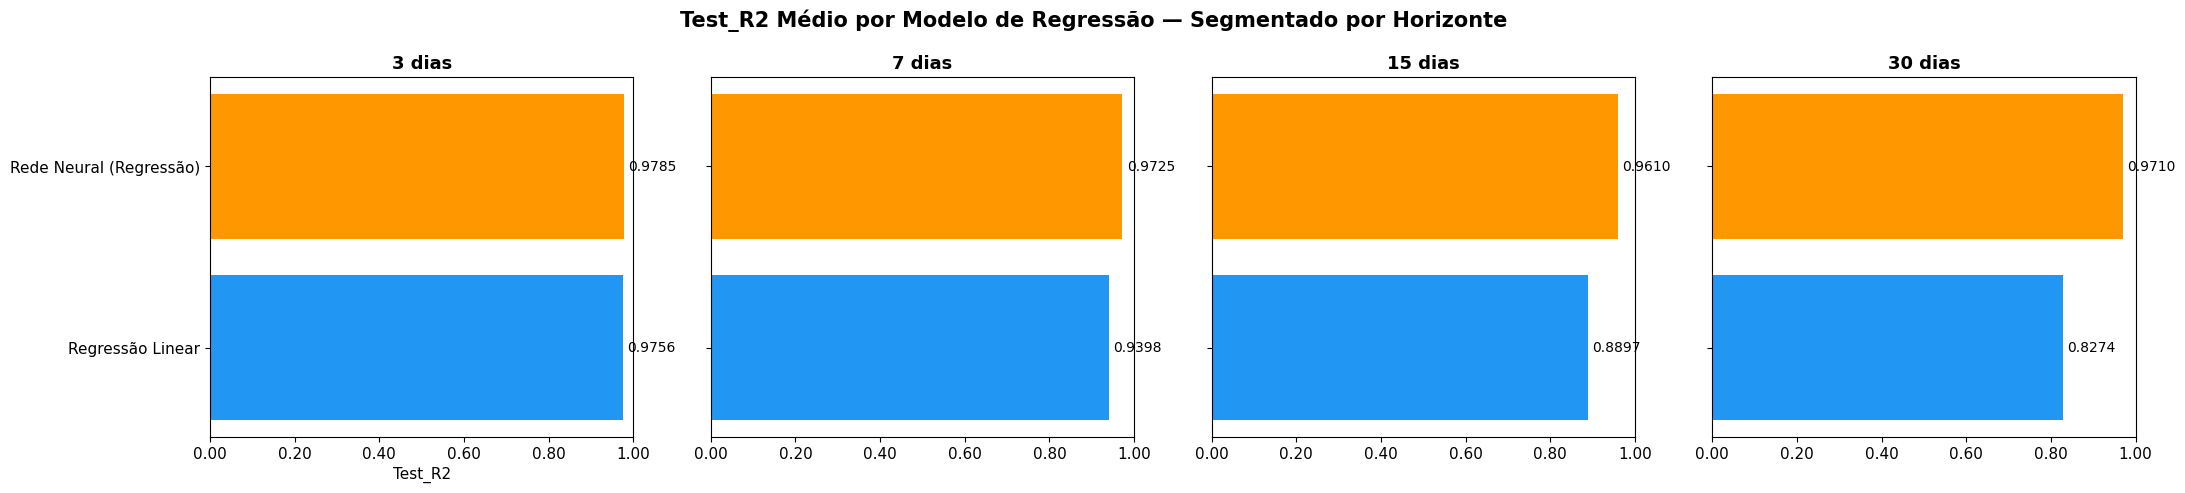

In [9]:
# ============================================================
# GRÁFICO: Test_R2 médio por modelo de regressão e horizonte
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('Test_R2 Médio por Modelo de Regressão — Segmentado por Horizonte', fontsize=15, fontweight='bold')

cores_regressao = ['#2196F3', '#FF9800']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue

    media = df_h.groupby('modelo_nome')['Test_R2'].mean().sort_values(ascending=True)
    bars = ax.barh(media.index, media.values, color=cores_regressao[:len(media)])
    ax.set_title(horizonte, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    for bar, val in zip(bars, media.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
                va='center', fontsize=10)

axes[0].set_xlabel('Test_R2')
plt.tight_layout()
plt.savefig('ranking_regressao_test_r2.png', bbox_inches='tight', dpi=150)
plt.show()

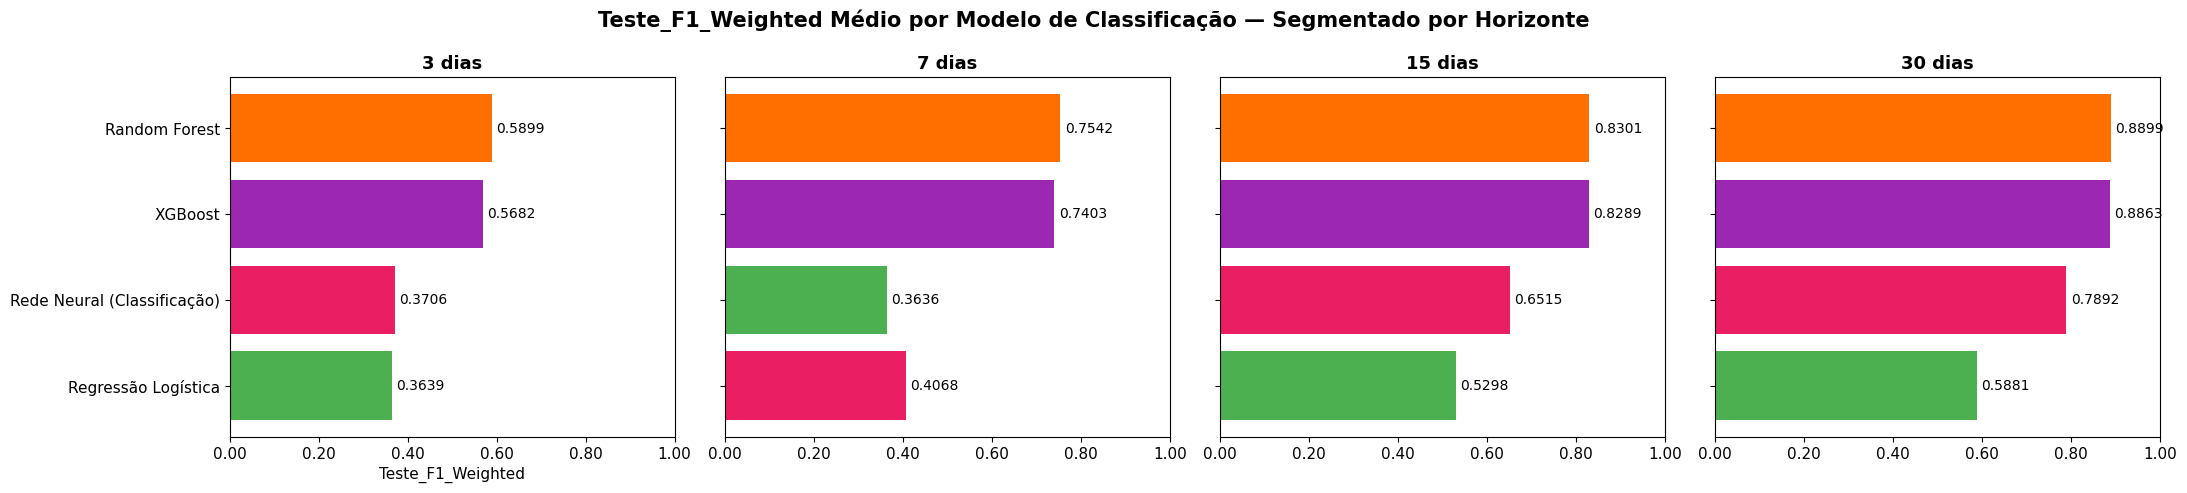

In [10]:
# ============================================================
# GRÁFICO: Teste_F1_Weighted médio por modelo de classificação e horizonte
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('Teste_F1_Weighted Médio por Modelo de Classificação — Segmentado por Horizonte', fontsize=15, fontweight='bold')

cores_classificacao = ['#4CAF50', '#E91E63', '#9C27B0', '#FF6F00']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue

    media = df_h.groupby('modelo_nome')['Teste_F1_Weighted'].mean().sort_values(ascending=True)
    bars = ax.barh(media.index, media.values, color=cores_classificacao[:len(media)])
    ax.set_title(horizonte, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    for bar, val in zip(bars, media.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
                va='center', fontsize=10)

axes[0].set_xlabel('Teste_F1_Weighted')
plt.tight_layout()
plt.savefig('ranking_classificacao_teste_f1_weighted.png', bbox_inches='tight', dpi=150)
plt.show()

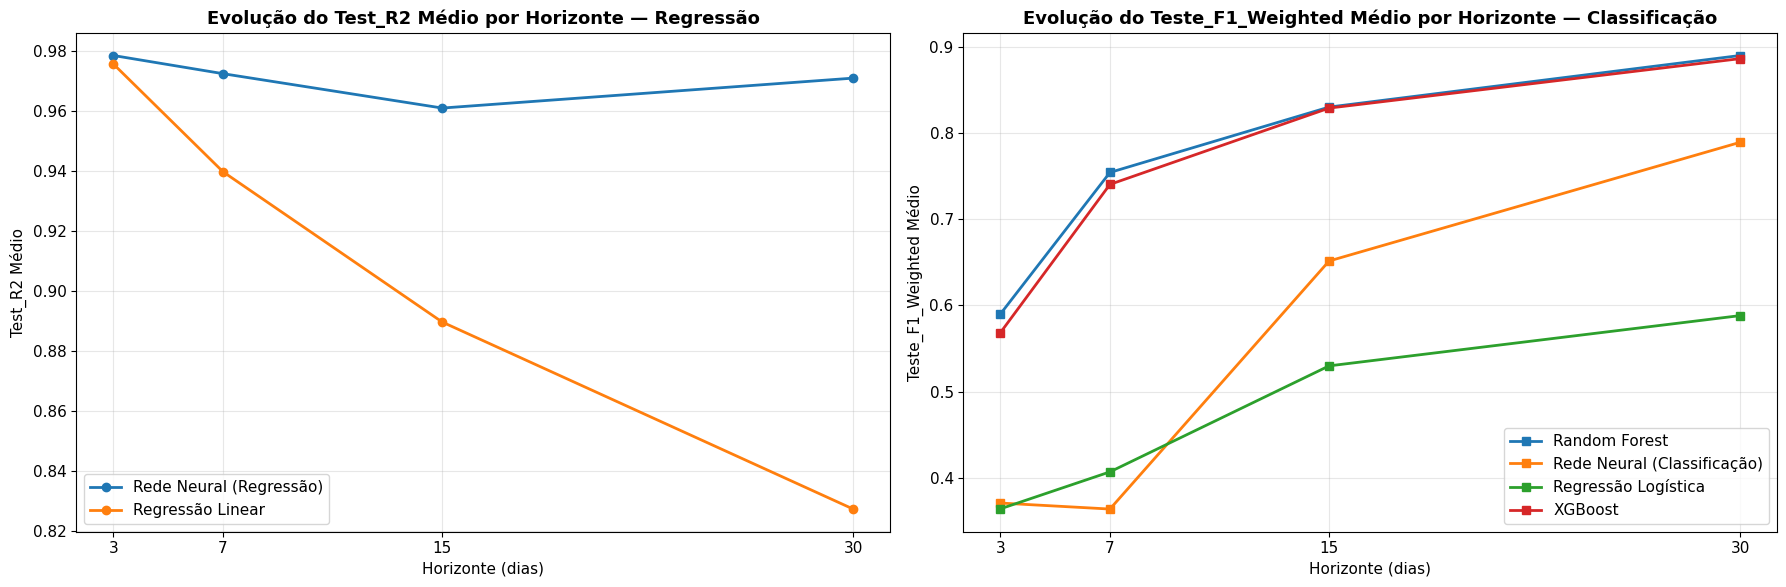

In [11]:
# ============================================================
# GRÁFICO: Evolução das métricas por horizonte (linha)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Regressão: Test_R2 por horizonte ---
ax = axes[0]
ax.set_title('Evolução do Test_R2 Médio por Horizonte — Regressão', fontsize=13, fontweight='bold')

for modelo in sorted(df_regressao['modelo_nome'].unique()):
    df_m = df_regressao[df_regressao['modelo_nome'] == modelo]
    medias = []
    for h in HORIZONTES:
        val = df_m[df_m['Horizonte'] == h]['Test_R2'].mean()
        medias.append(val)
    ax.plot([3, 7, 15, 30], medias, marker='o', linewidth=2, label=modelo)

ax.set_xlabel('Horizonte (dias)')
ax.set_ylabel('Test_R2 Médio')
ax.set_xticks([3, 7, 15, 30])
ax.legend()
ax.grid(True, alpha=0.3)

# --- Classificação: Teste_F1_Weighted por horizonte ---
ax = axes[1]
ax.set_title('Evolução do Teste_F1_Weighted Médio por Horizonte — Classificação', fontsize=13, fontweight='bold')

for modelo in sorted(df_classificacao['modelo_nome'].unique()):
    df_m = df_classificacao[df_classificacao['modelo_nome'] == modelo]
    medias = []
    for h in HORIZONTES:
        val = df_m[df_m['Horizonte'] == h]['Teste_F1_Weighted'].mean()
        medias.append(val)
    ax.plot([3, 7, 15, 30], medias, marker='s', linewidth=2, label=modelo)

ax.set_xlabel('Horizonte (dias)')
ax.set_ylabel('Teste_F1_Weighted Médio')
ax.set_xticks([3, 7, 15, 30])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolucao_metricas_horizonte.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Ranking por Ticker (detalhamento)

In [12]:
tickers = sorted(df_all['ticker'].unique())

print('=' * 80)
print('  RANKING POR TICKER — REGRESSÃO')
print('=' * 80)

for ticker in tickers:
    for horizonte in HORIZONTES:
        df_h = df_regressao[(df_regressao['ticker'] == ticker) & (df_regressao['Horizonte'] == horizonte)]
        if df_h.empty:
            continue

        df_h = df_h.sort_values('Test_R2', ascending=False).reset_index(drop=True)
        df_h.index = df_h.index + 1
        df_h.index.name = 'Ranking'

        print(f'\n--- {ticker} | {horizonte} ---')
        display(df_h[['modelo_nome', 'dataset_nome', 'Test_R2', 'Test_MAE', 'Test_RMSE', 'OOF_R2', 'OOF_MAE']].rename(columns={
            'modelo_nome': 'Modelo', 'dataset_nome': 'Dataset'
        }))

  RANKING POR TICKER — REGRESSÃO

--- AGRO3 | 3 dias ---


,Modelo,Dataset,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE
Ranking,,,,,,,
1,Rede Neural (Regressão),Dummy,0.9937,0.3386,0.4784,0.9919,0.3826
2,Rede Neural (Regressão),Base,0.9936,0.3420,0.4816,0.9919,0.3808
3,Rede Neural (Regressão),Indicadores,0.9925,0.3704,0.5157,0.9929,0.3567
4,Regressão Linear,Dummy,0.9910,0.3794,0.5711,0.9904,0.4047
5,Regressão Linear,Base,0.9908,0.3812,0.5782,0.9903,0.4073
6,Rede Neural (Regressão),Janelas,0.9906,0.4125,0.5798,0.9911,0.3955
7,Regressão Linear,Indicadores,0.9905,0.3892,0.5801,0.9900,0.4110
8,Regressão Linear,Janelas,0.9898,0.4188,0.6055,0.9905,0.3998



--- AGRO3 | 7 dias ---


,Modelo,Dataset,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE
Ranking,,,,,,,
1,Rede Neural (Regressão),Indicadores,0.9932,0.3552,0.4920,0.9915,0.3848
2,Rede Neural (Regressão),Dummy,0.9914,0.3897,0.5558,0.9897,0.4291
3,Rede Neural (Regressão),Base,0.9911,0.3965,0.5643,0.9887,0.4519
4,Rede Neural (Regressão),Janelas,0.9898,0.4312,0.6086,0.9867,0.4721
5,Regressão Linear,Dummy,0.9817,0.5678,0.8093,0.9781,0.6165
6,Regressão Linear,Base,0.9814,0.5666,0.8166,0.9773,0.6290
7,Regressão Linear,Janelas,0.9784,0.6115,0.8849,0.9778,0.6216
8,Regressão Linear,Indicadores,0.9765,0.6359,0.9143,0.9777,0.6243



--- AGRO3 | 15 dias ---


...

,Modelo,Dataset,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE
Ranking,,,,,,,
1,Rede Neural (Regressão),Indicadores,0.9457,0.3228,0.4361,0.9509,0.3445
2,Rede Neural (Regressão),Base,0.9330,0.3879,0.4921,0.9116,0.4521
3,Rede Neural (Regressão),Janelas,0.9322,0.3716,0.5077,0.9176,0.4214
4,Rede Neural (Regressão),Dummy,0.9251,0.3961,0.5205,0.9010,0.4540
5,Regressão Linear,Base,0.8696,0.5099,0.6866,0.8660,0.5611
6,Regressão Linear,Dummy,0.8689,0.5100,0.6886,0.8653,0.5615
7,Regressão Linear,Janelas,0.8514,0.5514,0.7514,0.8718,0.5451
8,Regressão Linear,Indicadores,0.8460,0.5593,0.7347,0.8734,0.5472



--- SOJA3 | 15 dias ---


,Modelo,Dataset,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE
Ranking,,,,,,,
1,Rede Neural (Regressão),Indicadores,0.9210,0.3973,0.5486,0.9405,0.3658
2,Rede Neural (Regressão),Janelas,0.9184,0.3927,0.5594,0.9262,0.4045
3,Rede Neural (Regressão),Dummy,0.8917,0.4876,0.6444,0.8826,0.4854
4,Rede Neural (Regressão),Base,0.8913,0.4837,0.6453,0.8973,0.4790
5,Regressão Linear,Base,0.7557,0.7412,0.9676,0.7367,0.7735
6,Regressão Linear,Dummy,0.7555,0.7409,0.9679,0.7366,0.7736
7,Regressão Linear,Indicadores,0.7555,0.7369,0.9650,0.7490,0.7770
8,Regressão Linear,Janelas,0.7029,0.8560,1.0677,0.7695,0.7401



--- SOJA3 | 30 dias ---


,Modelo,Dataset,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE
Ranking,,,,,,,
1,Rede Neural (Regressão),Indicadores,0.9627,0.3227,0.4002,0.9510,0.3387
2,Rede Neural (Regressão),Dummy,0.9461,0.3741,0.4870,0.9024,0.4616
3,Rede Neural (Regressão),Base,0.9460,0.3778,0.4872,0.8866,0.4909
4,Rede Neural (Regressão),Janelas,0.9333,0.4287,0.5263,0.9379,0.3856
5,Regressão Linear,Dummy,0.6376,1.0375,1.2627,0.6255,0.9847
6,Regressão Linear,Base,0.6281,1.0188,1.2791,0.5926,1.0180
7,Regressão Linear,Indicadores,0.6177,0.9986,1.2809,0.6136,0.9953
8,Regressão Linear,Janelas,0.6022,1.0332,1.2851,0.6006,1.0203


In [13]:
print('=' * 80)
print('  RANKING POR TICKER — CLASSIFICAÇÃO')
print('=' * 80)

for ticker in tickers:
    for horizonte in HORIZONTES:
        df_h = df_classificacao[(df_classificacao['ticker'] == ticker) & (df_classificacao['Horizonte'] == horizonte)]
        if df_h.empty:
            continue

        df_h = df_h.sort_values('Teste_F1_Weighted', ascending=False).reset_index(drop=True)
        df_h.index = df_h.index + 1
        df_h.index.name = 'Ranking'

        print(f'\n--- {ticker} | {horizonte} ---')
        display(df_h[['modelo_nome', 'dataset_nome', 'Teste_Accuracy', 'Teste_Precision', 'Teste_Recall', 'Teste_F1_Weighted', 'Teste_F1_Classe_Alta', 'Teste_AUC_ROC', 'CV_F1_Best', 'OOF_F1_Threshold']].rename(columns={
            'modelo_nome': 'Modelo', 'dataset_nome': 'Dataset'
        }))

  RANKING POR TICKER — CLASSIFICAÇÃO

--- AGRO3 | 3 dias ---


,Modelo,Dataset,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,XGBoost,Indicadores,0.7003,NaN,NaN,0.6809,0.7633,0.7725,0.6890,0.7234
2,Random Forest,Indicadores,0.6728,0.7163,0.6728,0.6498,0.7434,0.7617,0.6987,0.7342
3,Random Forest,Dummy,0.6284,0.6362,0.6284,0.6177,0.6870,0.6907,0.6798,0.7158
4,Random Forest,Janelas,0.6364,0.6716,0.6364,0.6097,0.7156,0.7026,0.6747,0.7148
5,Random Forest,Base,0.6163,0.6355,0.6163,0.5940,0.6940,0.6894,0.6819,0.7179
6,XGBoost,Base,0.5347,NaN,NaN,0.4757,0.6562,0.5390,0.6930,0.6982
7,XGBoost,Dummy,0.5347,NaN,NaN,0.4757,0.6562,0.5437,0.6936,0.6982
8,XGBoost,Janelas,0.5576,NaN,NaN,0.4688,0.6894,0.5755,0.6769,0.6946
9,Rede Neural (Classificação),Janelas,0.4667,NaN,NaN,0.4088,0.2414,0.5334,0.6840,0.6857



--- AGRO3 | 7 dias ---


,Modelo,Dataset,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,Random Forest,Indicadores,0.8073,0.8075,0.8073,0.8074,0.8225,0.8849,0.8235,0.8253
2,XGBoost,Indicadores,0.7920,NaN,NaN,0.7909,0.8162,0.8663,0.8076,0.8108
3,Random Forest,Janelas,0.7939,0.8080,0.7939,0.7882,0.8308,0.8852,0.7683,0.7846
4,Random Forest,Dummy,0.7885,0.8080,0.7885,0.7813,0.8284,0.8683,0.7827,0.7917
5,XGBoost,Base,0.7825,NaN,NaN,0.7801,0.8125,0.8468,0.7770,0.7787
6,XGBoost,Dummy,0.7855,NaN,NaN,0.7756,0.8297,0.8487,0.7745,0.7819
7,XGBoost,Janelas,0.7758,NaN,NaN,0.7722,0.8103,0.8681,0.7627,0.7722
8,Random Forest,Base,0.7795,0.8011,0.7795,0.7711,0.8224,0.8635,0.7709,0.7900
9,Rede Neural (Classificação),Janelas,0.5515,NaN,NaN,0.5359,0.6373,0.5783,0.7073,0.7122



--- AGRO3 | 15 dias ---


...

,Modelo,Dataset,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,Random Forest,Indicadores,0.7929,0.8002,0.7929,0.7918,0.8066,0.8618,0.7688,0.7793
2,XGBoost,Indicadores,0.7870,NaN,NaN,0.7869,0.7907,0.8714,0.7556,0.7827
3,XGBoost,Janelas,0.7076,NaN,NaN,0.7055,0.7283,0.7833,0.7404,0.7604
4,Random Forest,Dummy,0.7052,0.7160,0.7052,0.7018,0.7330,0.7927,0.7732,0.7846
5,Random Forest,Janelas,0.7018,0.7389,0.7018,0.6913,0.7463,0.7973,0.7422,0.7747
6,Random Forest,Base,0.6936,0.7088,0.6936,0.6884,0.7282,0.7771,0.7685,0.7855
7,XGBoost,Dummy,0.6532,NaN,NaN,0.6442,0.7000,0.7572,0.7427,0.7649
8,XGBoost,Base,0.6358,NaN,NaN,0.6020,0.7175,0.7420,0.7375,0.7566
9,Regressão Logística,Janelas,0.5263,NaN,NaN,0.3971,0.6747,0.6025,0.5558,0.6653



--- SOJA3 | 15 dias ---


,Modelo,Dataset,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,XGBoost,Base,0.8555,NaN,NaN,0.8556,0.8521,0.9184,0.8161,0.8253
2,XGBoost,Dummy,0.8497,NaN,NaN,0.8498,0.8488,0.9299,0.8160,0.8395
3,XGBoost,Janelas,0.8421,NaN,NaN,0.8421,0.8421,0.9346,0.8184,0.8228
4,Random Forest,Indicadores,0.8343,0.8382,0.8343,0.8344,0.8333,0.9338,0.8811,0.8824
5,XGBoost,Indicadores,0.8284,NaN,NaN,0.8284,0.8284,0.9029,0.8662,0.8669
6,Random Forest,Base,0.8266,0.8288,0.8266,0.8267,0.8235,0.9246,0.8343,0.8384
7,Random Forest,Dummy,0.8092,0.8121,0.8092,0.8093,0.8070,0.9248,0.8379,0.8508
8,Random Forest,Janelas,0.7895,0.8055,0.7895,0.7886,0.7978,0.9095,0.7991,0.8070
9,Rede Neural (Classificação),Indicadores,0.7041,NaN,NaN,0.6951,0.7423,0.7688,0.6975,0.7402



--- SOJA3 | 30 dias ---


,Modelo,Dataset,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Ranking,,,,,,,,,,
1,Random Forest,Dummy,0.9017,0.9126,0.9017,0.9021,0.8970,0.9795,0.8655,0.8711
2,XGBoost,Janelas,0.9006,NaN,NaN,0.9007,0.8874,0.9732,0.8475,0.8499
3,XGBoost,Dummy,0.8960,NaN,NaN,0.8963,0.8861,0.9703,0.8481,0.8623
4,Random Forest,Janelas,0.8947,0.8976,0.8947,0.8951,0.8846,0.9610,0.8422,0.8571
5,XGBoost,Base,0.8902,NaN,NaN,0.8906,0.8848,0.9653,0.8403,0.8507
6,Random Forest,Base,0.8902,0.8923,0.8902,0.8905,0.8790,0.9756,0.8619,0.8628
7,Random Forest,Indicadores,0.8698,0.8792,0.8698,0.8701,0.8659,0.9607,0.8885,0.8923
8,XGBoost,Indicadores,0.8580,NaN,NaN,0.8577,0.8605,0.9574,0.8956,0.9015
9,Rede Neural (Classificação),Dummy,0.8266,NaN,NaN,0.8271,0.8214,0.9362,0.7619,0.7875


---
## 8. Heatmaps: Desempenho por Modelo × Dataset

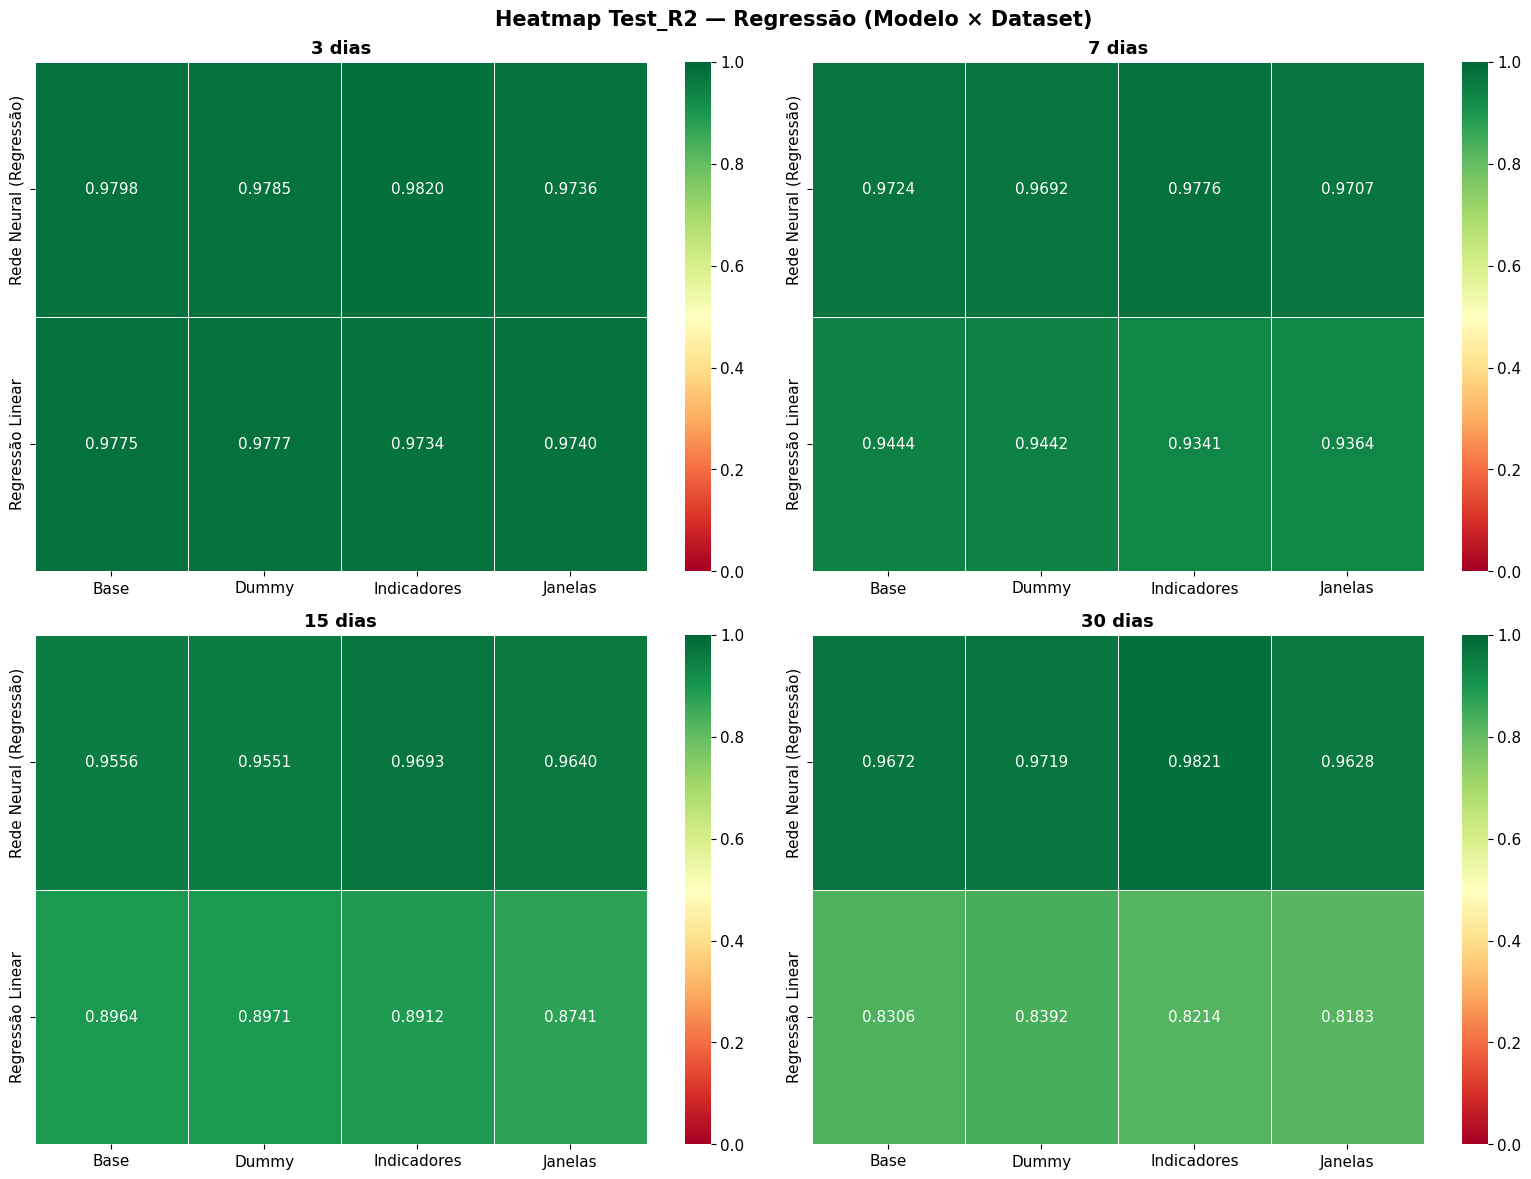

In [14]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heatmap Test_R2 — Regressão (Modelo × Dataset)', fontsize=15, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i // 2][i % 2]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]

    if df_h.empty:
        ax.set_title(f'{horizonte} (sem dados)')
        continue

    pivot = df_h.pivot_table(
        values='Test_R2', index='modelo_nome', columns='dataset_nome', aggfunc='mean'
    )

    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{horizonte}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_regressao_test_r2.png', bbox_inches='tight', dpi=150)
plt.show()

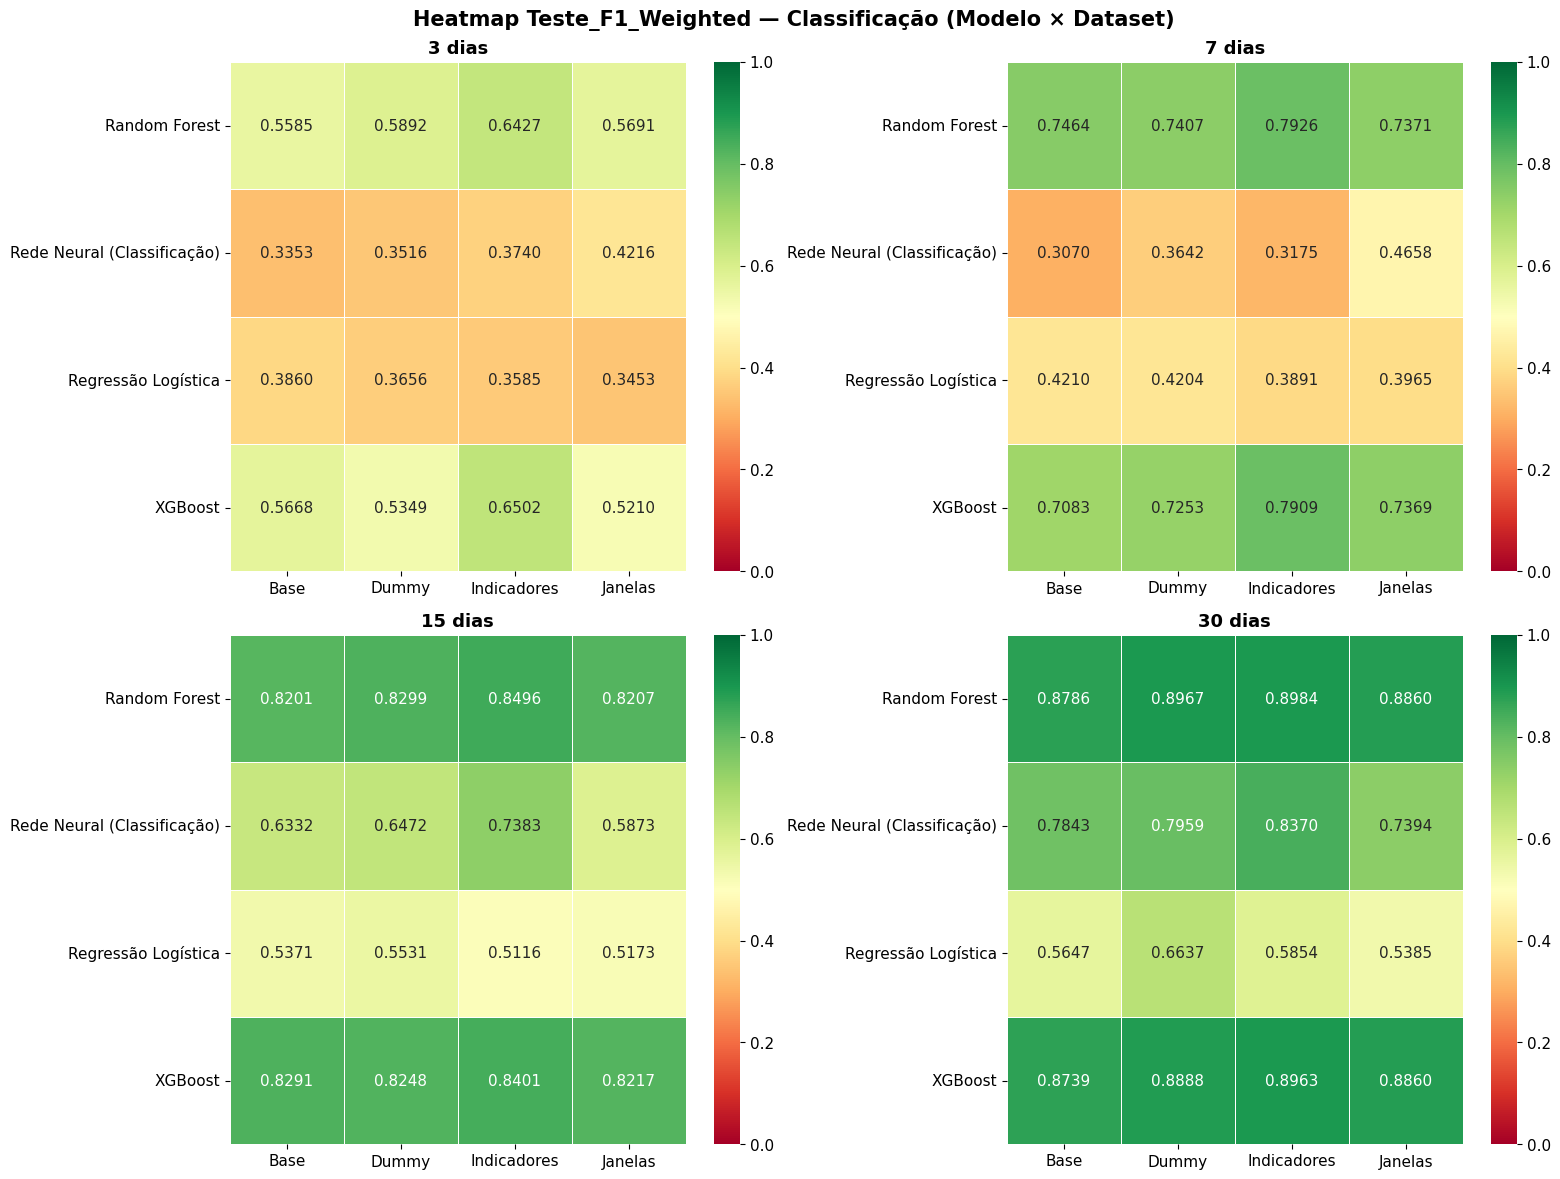

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heatmap Teste_F1_Weighted — Classificação (Modelo × Dataset)', fontsize=15, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i // 2][i % 2]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]

    if df_h.empty:
        ax.set_title(f'{horizonte} (sem dados)')
        continue

    pivot = df_h.pivot_table(
        values='Teste_F1_Weighted', index='modelo_nome', columns='dataset_nome', aggfunc='mean'
    )

    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{horizonte}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_classificacao_teste_f1_weighted.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Resumo Final: Melhor Modelo por Horizonte

In [16]:
print('=' * 80)
print('  MELHOR MODELO POR HORIZONTE')
print('=' * 80)

resumo_regressao = []
resumo_classificacao = []

for horizonte in HORIZONTES:
    # Regressão: melhor Test_R2
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if not df_h.empty:
        best = df_h.loc[df_h['Test_R2'].idxmax()]
        resumo_regressao.append({
            'Horizonte': horizonte,
            'Modelo': best['modelo_nome'],
            'Dataset': best['dataset_nome'],
            'Ticker': best['ticker'],
            'Test_R2': best['Test_R2'],
            'Test_MAE': best['Test_MAE'],
            'Test_RMSE': best['Test_RMSE'],
            'OOF_R2': best.get('OOF_R2'),
            'OOF_MAE': best.get('OOF_MAE'),
            'CV_MAE': best.get('CV_MAE'),
        })

    # Classificação: melhor Teste_F1_Weighted
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if not df_h.empty:
        best = df_h.loc[df_h['Teste_F1_Weighted'].idxmax()]
        resumo_classificacao.append({
            'Horizonte': horizonte,
            'Modelo': best['modelo_nome'],
            'Dataset': best['dataset_nome'],
            'Ticker': best['ticker'],
            'Teste_Accuracy': best.get('Teste_Accuracy'),
            'Teste_Precision': best.get('Teste_Precision'),
            'Teste_Recall': best.get('Teste_Recall'),
            'Teste_F1_Weighted': best['Teste_F1_Weighted'],
            'Teste_F1_Classe_Alta': best.get('Teste_F1_Classe_Alta'),
            'Teste_AUC_ROC': best.get('Teste_AUC_ROC'),
            'CV_F1_Best': best.get('CV_F1_Best'),
            'OOF_F1_Threshold': best.get('OOF_F1_Threshold'),
        })

print('\n--- Regressão (melhor Test_R2) ---')
display(pd.DataFrame(resumo_regressao).set_index('Horizonte'))

print('\n--- Classificação (melhor Teste_F1_Weighted) ---')
display(pd.DataFrame(resumo_classificacao).set_index('Horizonte'))

  MELHOR MODELO POR HORIZONTE

--- Regressão (melhor Test_R2) ---


,Modelo,Dataset,Ticker,Test_R2,Test_MAE,Test_RMSE,OOF_R2,OOF_MAE,CV_MAE
Horizonte,,,,,,,,,
3 dias,Rede Neural (Regressão),Dummy,SLCE3,0.9942,0.3027,0.4089,0.9914,0.3513,0.3513
7 dias,Rede Neural (Regressão),Indicadores,SLCE3,0.9937,0.3120,0.4211,0.9918,0.3453,0.3453
15 dias,Rede Neural (Regressão),Indicadores,AGRO3,0.9938,0.3392,0.4682,0.9906,0.4105,0.4105
30 dias,Rede Neural (Regressão),Indicadores,SLCE3,0.9921,0.3592,0.4654,0.9896,0.3776,0.3776



--- Classificação (melhor Teste_F1_Weighted) ---


,Modelo,Dataset,Ticker,Teste_Accuracy,Teste_Precision,Teste_Recall,Teste_F1_Weighted,Teste_F1_Classe_Alta,Teste_AUC_ROC,CV_F1_Best,OOF_F1_Threshold
Horizonte,,,,,,,,,,,
3 dias,XGBoost,Indicadores,SOJA3,0.6864,NaN,NaN,0.6864,0.6864,0.7746,0.6790,0.6894
7 dias,Random Forest,Indicadores,AGRO3,0.8073,0.8075,0.8073,0.8074,0.8225,0.8849,0.8235,0.8253
15 dias,Random Forest,Indicadores,AGRO3,0.8777,0.8787,0.8777,0.8779,0.8889,0.9393,0.8875,0.8901
30 dias,Random Forest,Indicadores,SLCE3,0.9205,0.9206,0.9205,0.9204,0.9282,0.9671,0.9052,0.9067


---
## 10. Exportar Rankings Consolidados

In [17]:
# Exportar CSVs consolidados para análise posterior
output_dir = os.path.dirname(os.path.abspath('__file__'))

df_regressao.to_csv(os.path.join(output_dir, 'consolidado_regressao.csv'), index=False)
df_classificacao.to_csv(os.path.join(output_dir, 'consolidado_classificacao.csv'), index=False)


# ----------------------------------------------------------------------------
# Geracao de estatisticas estendidas: media, mediana, desvio padrao e
# coeficiente de variacao (CV = std / |mean|), por modelo e horizonte.
#
# Atencao: o termo "CV" aqui pode ser ambiguo — no projeto:
#   - "CV F1", "CV MAE" (em colunas como CV_F1_Best, CV_MAE) referem-se a
#     Cross-Validation (validacao cruzada interna do RandomizedSearchCV).
#   - O coeficiente de variacao (estatistica) eh exportado como sufixo
#     "_coefvar" para evitar confusao.
# ----------------------------------------------------------------------------

METRICAS_REGRESSAO = ['Test_R2', 'Test_MAE', 'Test_RMSE', 'OOF_R2', 'OOF_MAE', 'CV_MAE']
METRICAS_CLASSIFICACAO = [
    'Teste_Accuracy', 'Teste_Precision', 'Teste_Recall',
    'Teste_F1_Weighted', 'Teste_F1_Classe_Alta', 'Teste_AUC_ROC',
    'CV_F1_Best', 'OOF_F1_Threshold',
]


def estatisticas_estendidas(df_grupo, metricas):
    """Calcula media, mediana, desvio padrao e coef. variacao para cada metrica.

    Retorna um DataFrame achatado com colunas no formato:
        '<metrica>_mean', '<metrica>_median', '<metrica>_std', '<metrica>_coefvar'

    O coef. variacao (CV) eh definido como std / |mean|. Quando |mean| < 1e-9,
    o valor eh considerado indefinido (NaN) para evitar divisao por zero.
    """
    agg = df_grupo[metricas].agg(['mean', 'median', 'std'])
    out = {}
    for m in metricas:
        mean = agg.loc['mean', m]
        median = agg.loc['median', m]
        std = agg.loc['std', m]
        if pd.notna(mean) and abs(mean) > 1e-9:
            cv = std / abs(mean)
        else:
            cv = float('nan')
        out[f'{m}_mean'] = mean
        out[f'{m}_median'] = median
        out[f'{m}_std'] = std
        out[f'{m}_coefvar'] = cv
    return pd.Series(out)


# Rankings com estatisticas estendidas (media, mediana, std, CV) — versao expandida
ranking_estendido_reg = []
ranking_estendido_clf = []

# Rankings legados — apenas com a media (mantidos por compatibilidade com codigo antigo)
ranking_medio_reg = []
ranking_medio_clf = []

for horizonte in HORIZONTES:
    # ---------- Regressao ----------
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if not df_h.empty:
        # Versao estendida (4 estatisticas por metrica)
        estat = (
            df_h.groupby('modelo_nome')
                .apply(lambda g: estatisticas_estendidas(g, METRICAS_REGRESSAO))
                .reset_index()
        )
        estat['Horizonte'] = horizonte
        ranking_estendido_reg.append(estat)

        # Versao legada (apenas media)
        media = df_h.groupby('modelo_nome')[METRICAS_REGRESSAO].mean().reset_index()
        media['Horizonte'] = horizonte
        ranking_medio_reg.append(media)

    # ---------- Classificacao ----------
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if not df_h.empty:
        # Versao estendida
        estat = (
            df_h.groupby('modelo_nome')
                .apply(lambda g: estatisticas_estendidas(g, METRICAS_CLASSIFICACAO))
                .reset_index()
        )
        estat['Horizonte'] = horizonte
        ranking_estendido_clf.append(estat)

        # Versao legada
        media = df_h.groupby('modelo_nome')[METRICAS_CLASSIFICACAO].mean().reset_index()
        media['Horizonte'] = horizonte
        ranking_medio_clf.append(media)

# Salvar versao legada (compatibilidade com o que ja existia)
if ranking_medio_reg:
    pd.concat(ranking_medio_reg).to_csv(
        os.path.join(output_dir, 'ranking_medio_regressao.csv'), index=False
    )
if ranking_medio_clf:
    pd.concat(ranking_medio_clf).to_csv(
        os.path.join(output_dir, 'ranking_medio_classificacao.csv'), index=False
    )

# Salvar versao estendida (com mediana, std e coef. variacao)
if ranking_estendido_reg:
    pd.concat(ranking_estendido_reg).to_csv(
        os.path.join(output_dir, 'ranking_estatisticas_regressao.csv'), index=False
    )
if ranking_estendido_clf:
    pd.concat(ranking_estendido_clf).to_csv(
        os.path.join(output_dir, 'ranking_estatisticas_classificacao.csv'), index=False
    )

print('Arquivos exportados com sucesso:')
print('  - consolidado_regressao.csv')
print('  - consolidado_classificacao.csv')
print('  - ranking_medio_regressao.csv         (apenas media)')
print('  - ranking_medio_classificacao.csv     (apenas media)')
print('  - ranking_estatisticas_regressao.csv  (mean, median, std, coefvar)')
print('  - ranking_estatisticas_classificacao.csv (mean, median, std, coefvar)')

Arquivos exportados com sucesso:
  - consolidado_regressao.csv
  - consolidado_classificacao.csv
  - ranking_medio_regressao.csv         (apenas media)
  - ranking_medio_classificacao.csv     (apenas media)
  - ranking_estatisticas_regressao.csv  (mean, median, std, coefvar)
  - ranking_estatisticas_classificacao.csv (mean, median, std, coefvar)


---
## 11. Estatísticas Estendidas (Média, Mediana, Desvio Padrão e Coeficiente de Variação)

A média sozinha esconde a dispersão dos resultados entre os 12 cenários (3 empresas × 4 datasets) que cada modelo cobre em cada horizonte. As tabelas a seguir consolidam quatro estatísticas para a métrica primária de cada tarefa:

- **Média** ($\mu$): tendência central
- **Mediana**: tendência central robusta a outliers
- **Desvio padrão** ($\sigma$): dispersão absoluta
- **Coef. de variação** ($CV = \sigma / |\mu|$): dispersão relativa, comparável entre modelos com escalas diferentes

> **Atenção à ambiguidade**: "CV" no nome de coluna `CV_F1_Best` e `CV_MAE` refere-se à **C**ross-**V**alidation interna do `RandomizedSearchCV`. O **coeficiente de variação** estatístico aparece com sufixo `_coefvar` para evitar confusão.

In [18]:
# ============================================================
# Tabelas estendidas: REGRESSAO (Test_R2) por horizonte
# ============================================================

print('=' * 90)
print('  ESTATISTICAS ESTENDIDAS - REGRESSAO (metrica primaria: Test_R2)')
print('=' * 90)

for horizonte in HORIZONTES:
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        continue

    estat = (
        df_h.groupby('modelo_nome')['Test_R2']
            .agg(['mean', 'median', 'std'])
            .round(4)
    )
    estat['coefvar'] = (estat['std'] / estat['mean'].abs()).round(4)
    estat = estat.sort_values('mean', ascending=False)
    estat.index.name = 'Modelo'
    estat.columns = ['Media', 'Mediana', 'Desvio Padrao', 'Coef. Variacao']

    print(f'\n--- {horizonte} ---')
    display(estat)


# ============================================================
# Tabelas estendidas: CLASSIFICACAO (Teste_F1_Classe_Alta) por horizonte
# ============================================================

print('\n\n' + '=' * 90)
print('  ESTATISTICAS ESTENDIDAS - CLASSIFICACAO (metrica primaria: F1 da classe Alta)')
print('=' * 90)

for horizonte in HORIZONTES:
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        continue

    estat = (
        df_h.groupby('modelo_nome')['Teste_F1_Classe_Alta']
            .agg(['mean', 'median', 'std'])
            .round(4)
    )
    estat['coefvar'] = (estat['std'] / estat['mean'].abs()).round(4)
    estat = estat.sort_values('mean', ascending=False)
    estat.index.name = 'Modelo'
    estat.columns = ['Media', 'Mediana', 'Desvio Padrao', 'Coef. Variacao']

    print(f'\n--- {horizonte} ---')
    display(estat)

  ESTATISTICAS ESTENDIDAS - REGRESSAO (metrica primaria: Test_R2)

--- 3 dias ---


,Media,Mediana,Desvio Padrao,Coef. Variacao
Modelo,,,,
Rede Neural (Regressão),0.9785,0.9916,0.0215,0.0220
Regressão Linear,0.9756,0.9902,0.0222,0.0228



--- 7 dias ---


,Media,Mediana,Desvio Padrao,Coef. Variacao
Modelo,,,,
Rede Neural (Regressão),0.9725,0.9907,0.0288,0.0296
Regressão Linear,0.9398,0.9788,0.0600,0.0638



--- 15 dias ---


...

,Media,Mediana,Desvio Padrao,Coef. Variacao
Modelo,,,,
Random Forest,0.7907,0.8081,0.0386,0.0488
XGBoost,0.7821,0.8015,0.0454,0.0580
Regressão Logística,0.6914,0.6967,0.0168,0.0243
Rede Neural (Classificação),0.3028,0.1250,0.3378,1.1156



--- 15 dias ---


,Media,Mediana,Desvio Padrao,Coef. Variacao
Modelo,,,,
XGBoost,0.8485,0.8487,0.0116,0.0137
Random Forest,0.8458,0.8507,0.0264,0.0312
Rede Neural (Classificação),0.7242,0.7551,0.0841,0.1161
Regressão Logística,0.7094,0.7229,0.0283,0.0399



--- 30 dias ---


,Media,Mediana,Desvio Padrao,Coef. Variacao
Modelo,,,,
Random Forest,0.8972,0.8938,0.0182,0.0203
XGBoost,0.8936,0.8891,0.0191,0.0214
Rede Neural (Classificação),0.8158,0.8206,0.0409,0.0501
Regressão Logística,0.7289,0.7418,0.0385,0.0528


---
## 12. Visualizações com Dispersão (Média ± Desvio Padrão)

Os gráficos a seguir reproduzem os rankings da Seção 6 mas adicionam barras de erro representando ± 1 desvio padrão. Permitem visualizar imediatamente quais modelos têm vantagem estatisticamente robusta (sem sobreposição de barras de erro) e quais empatam dentro da margem de variação.

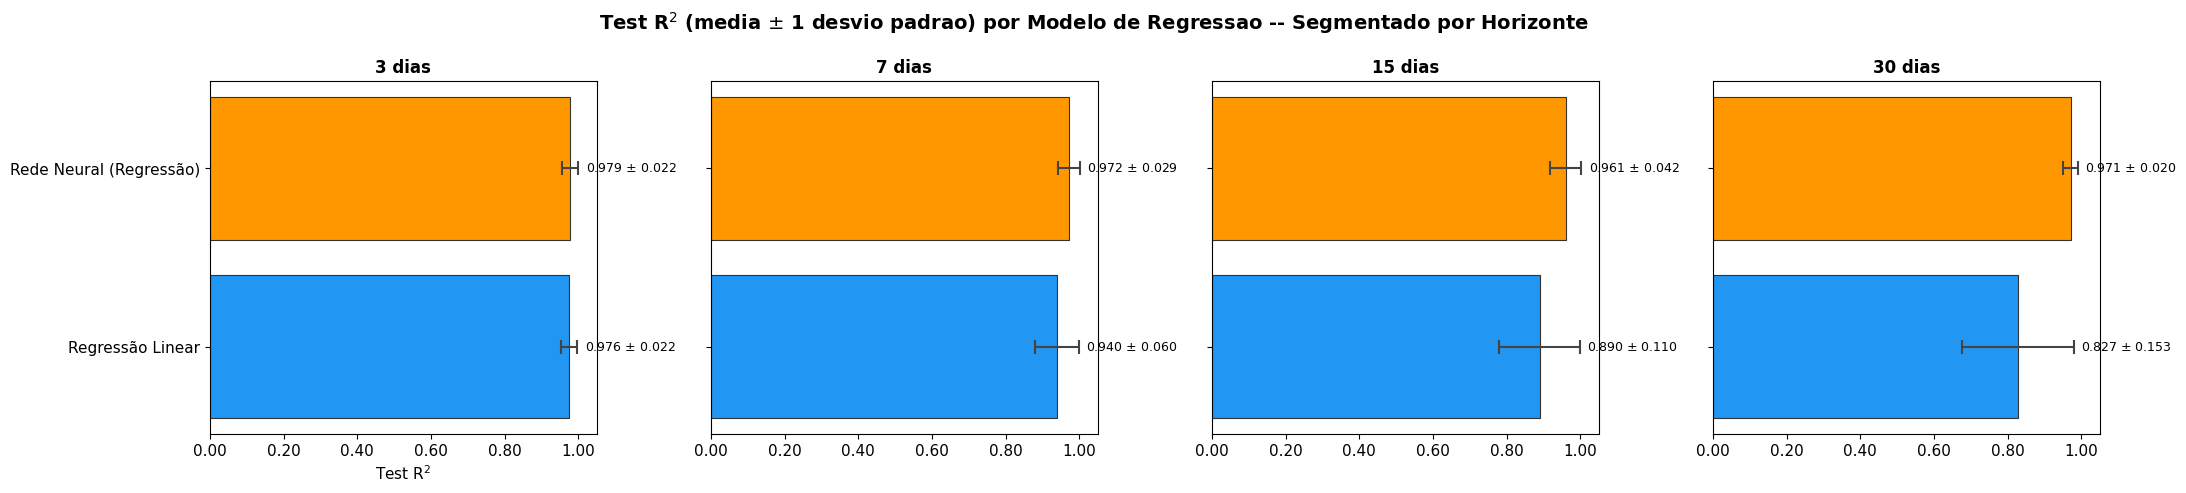

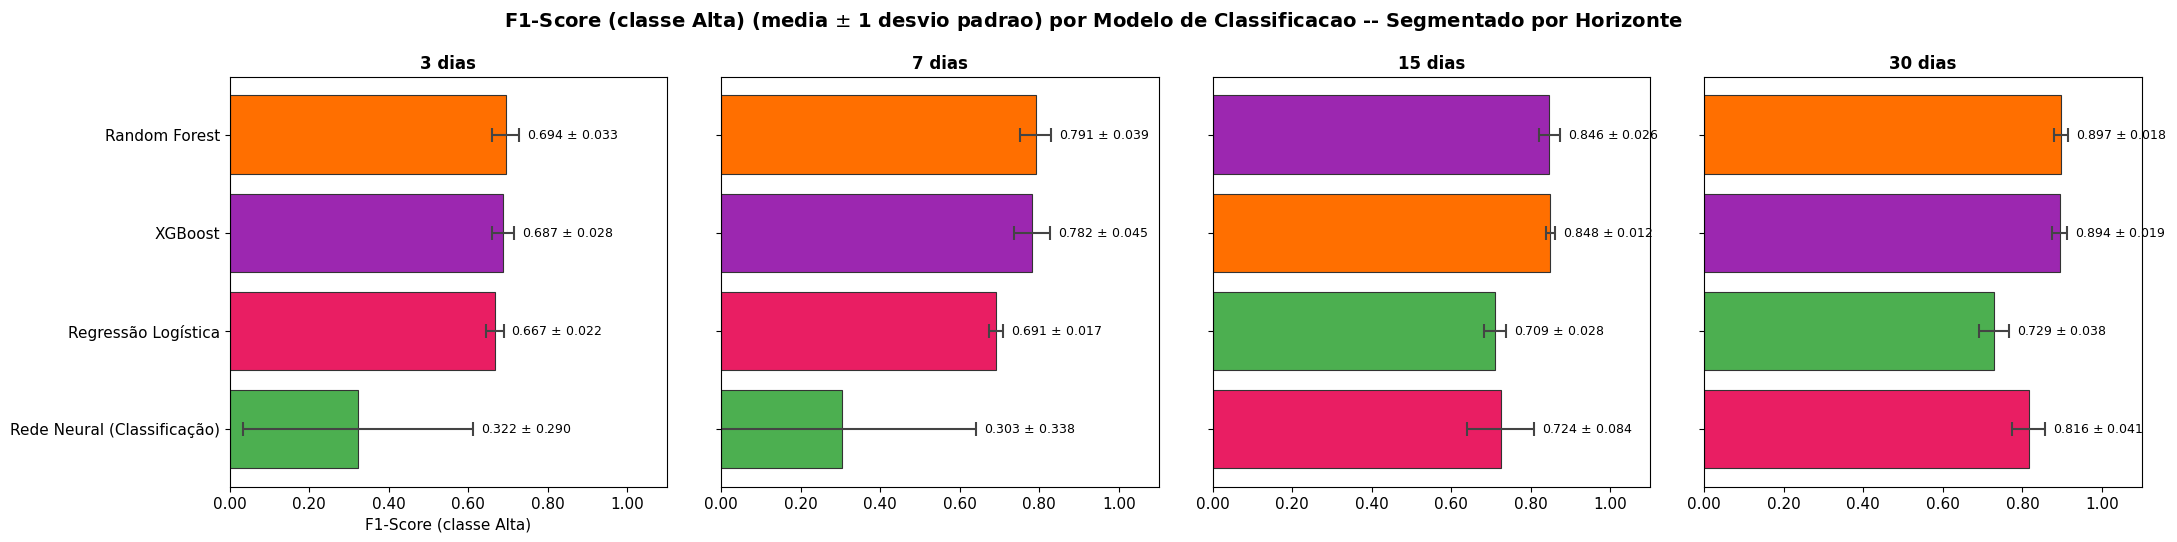

In [19]:
# ============================================================
# GRAFICO: Test_R2 medio +/- std por modelo de regressao
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('Test R$^2$ (media $\\pm$ 1 desvio padrao) por Modelo de Regressao -- Segmentado por Horizonte',
             fontsize=14, fontweight='bold')

cores_regressao = ['#2196F3', '#FF9800']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue

    estat = (
        df_h.groupby('modelo_nome')['Test_R2']
            .agg(['mean', 'std'])
            .sort_values('mean', ascending=True)
    )

    bars = ax.barh(
        estat.index, estat['mean'], xerr=estat['std'],
        color=cores_regressao[:len(estat)],
        edgecolor='#333', linewidth=0.8,
        error_kw={'ecolor': '#444', 'capsize': 5, 'capthick': 1.5, 'lw': 1.5},
    )
    ax.set_title(horizonte, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    for bar, mean, std in zip(bars, estat['mean'], estat['std']):
        ax.text(min(mean + std + 0.02, 1.04), bar.get_y() + bar.get_height() / 2,
                f'{mean:.3f} $\\pm$ {std:.3f}',
                va='center', fontsize=9)

axes[0].set_xlabel('Test R$^2$')
plt.tight_layout()
plt.savefig('ranking_regressao_test_r2_std.png', bbox_inches='tight', dpi=150)
plt.show()


# ============================================================
# GRAFICO: F1 da classe Alta media +/- std por modelo de classificacao
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)
fig.suptitle('F1-Score (classe Alta) (media $\\pm$ 1 desvio padrao) por Modelo de Classificacao -- Segmentado por Horizonte',
             fontsize=14, fontweight='bold')

cores_classificacao = ['#4CAF50', '#E91E63', '#9C27B0', '#FF6F00']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue

    estat = (
        df_h.groupby('modelo_nome')['Teste_F1_Classe_Alta']
            .agg(['mean', 'std'])
            .sort_values('mean', ascending=True)
    )

    bars = ax.barh(
        estat.index, estat['mean'], xerr=estat['std'],
        color=cores_classificacao[:len(estat)],
        edgecolor='#333', linewidth=0.8,
        error_kw={'ecolor': '#444', 'capsize': 5, 'capthick': 1.5, 'lw': 1.5},
    )
    ax.set_title(horizonte, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.10)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    for bar, mean, std in zip(bars, estat['mean'], estat['std']):
        ax.text(min(mean + std + 0.02, 1.08), bar.get_y() + bar.get_height() / 2,
                f'{mean:.3f} $\\pm$ {std:.3f}',
                va='center', fontsize=9)

axes[0].set_xlabel('F1-Score (classe Alta)')
plt.tight_layout()
plt.savefig('ranking_classificacao_f1alta_std.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 13. Box-plots: Distribuição Completa por Modelo × Horizonte

Os box-plots a seguir mostram, simultaneamente, a mediana (linha central), o intervalo interquartil (caixa), os "bigodes" (1,5 × IQR) e os outliers (pontos isolados) das métricas primárias para cada modelo em cada horizonte. Diferentemente das barras com erro padrão, **não assumem distribuição normal** — são robustos a outliers e mostram a forma real da distribuição dos 12 cenários por célula.

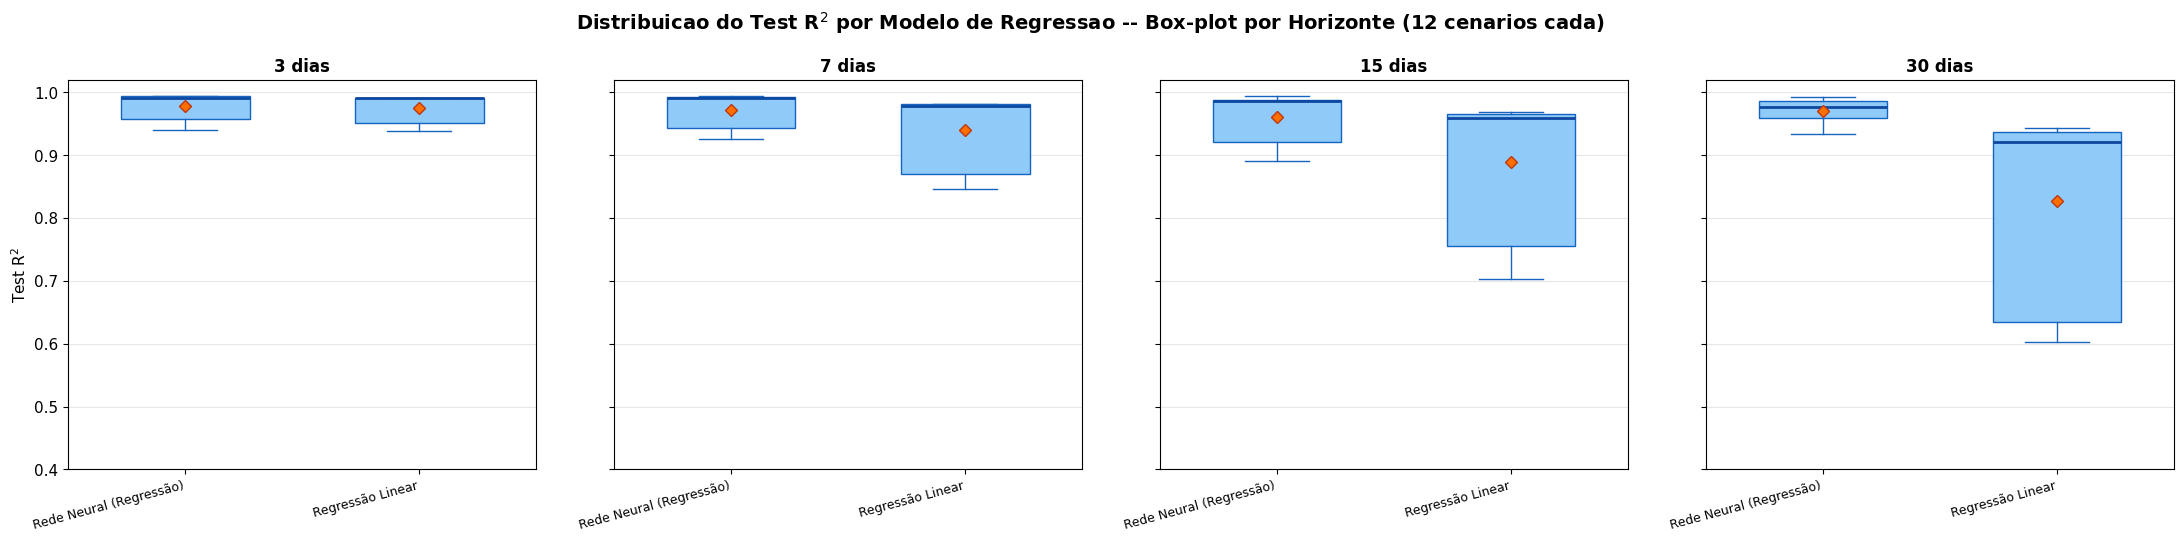

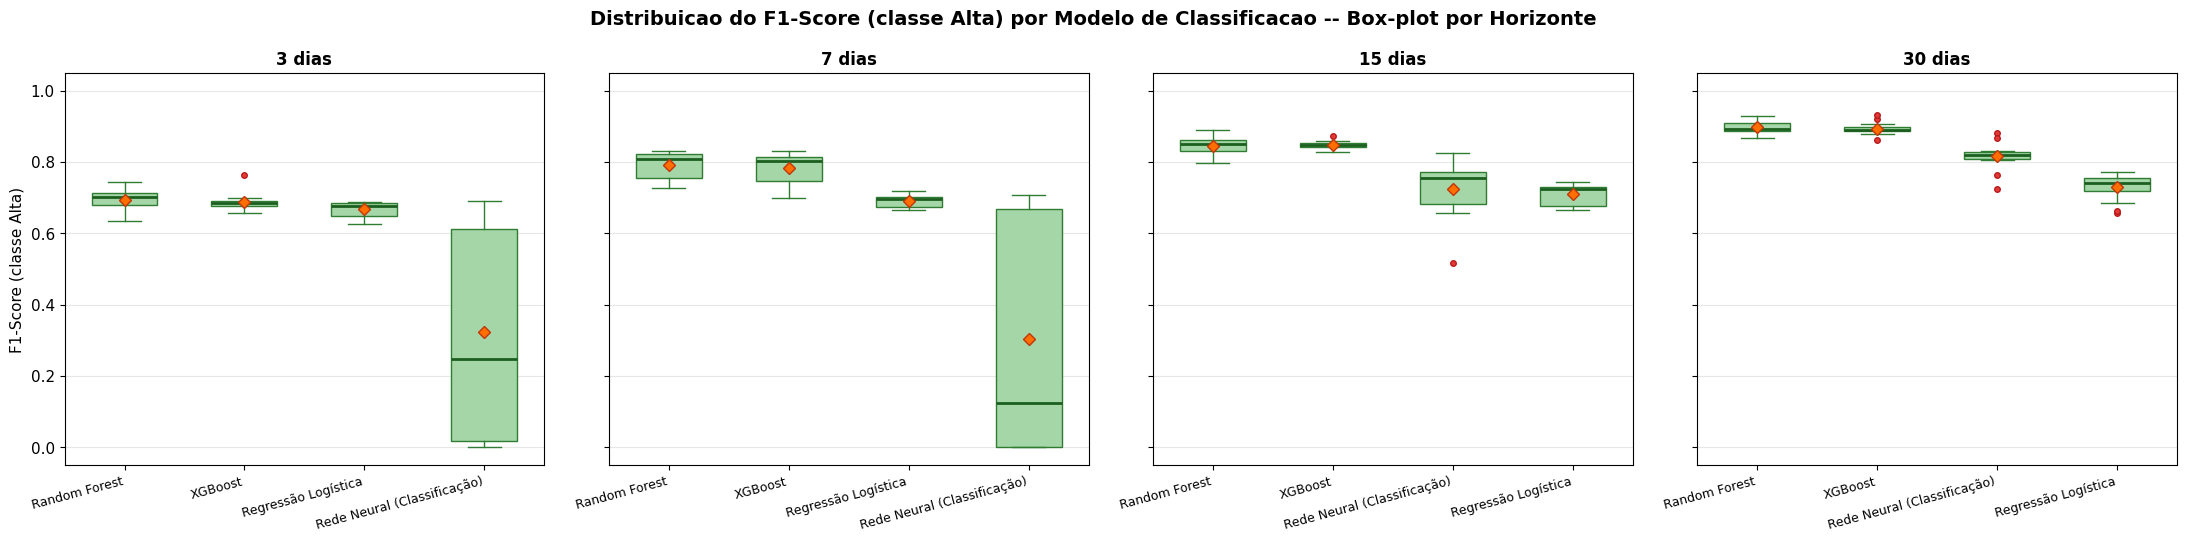

In [20]:
# ============================================================
# BOXPLOT: Test_R2 por modelo (regressao) - 4 horizontes
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)
fig.suptitle('Distribuicao do Test R$^2$ por Modelo de Regressao -- Box-plot por Horizonte (12 cenarios cada)',
             fontsize=14, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue

    modelos_ordenados = (
        df_h.groupby('modelo_nome')['Test_R2'].median().sort_values(ascending=False).index.tolist()
    )
    dados = [df_h[df_h['modelo_nome'] == m]['Test_R2'].values for m in modelos_ordenados]

    bp = ax.boxplot(
        dados, labels=modelos_ordenados, patch_artist=True,
        widths=0.55, showmeans=True, meanline=False,
        boxprops=dict(facecolor='#90caf9', edgecolor='#1565c0'),
        medianprops=dict(color='#0d47a1', linewidth=2),
        meanprops=dict(marker='D', markerfacecolor='#ff6f00', markeredgecolor='#bf360c', markersize=6),
        whiskerprops=dict(color='#1565c0'),
        capprops=dict(color='#1565c0'),
        flierprops=dict(marker='o', markerfacecolor='#e53935', markersize=4, markeredgecolor='#b71c1c'),
    )
    ax.set_title(horizonte, fontsize=12, fontweight='bold')
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

axes[0].set_ylabel('Test R$^2$')
plt.tight_layout()
plt.savefig('boxplot_regressao_test_r2.png', bbox_inches='tight', dpi=150)
plt.show()


# ============================================================
# BOXPLOT: F1 da classe Alta por modelo (classificacao) - 4 horizontes
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)
fig.suptitle('Distribuicao do F1-Score (classe Alta) por Modelo de Classificacao -- Box-plot por Horizonte',
             fontsize=14, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue

    modelos_ordenados = (
        df_h.groupby('modelo_nome')['Teste_F1_Classe_Alta'].median().sort_values(ascending=False).index.tolist()
    )
    dados = [df_h[df_h['modelo_nome'] == m]['Teste_F1_Classe_Alta'].values for m in modelos_ordenados]

    bp = ax.boxplot(
        dados, labels=modelos_ordenados, patch_artist=True,
        widths=0.55, showmeans=True, meanline=False,
        boxprops=dict(facecolor='#a5d6a7', edgecolor='#2e7d32'),
        medianprops=dict(color='#1b5e20', linewidth=2),
        meanprops=dict(marker='D', markerfacecolor='#ff6f00', markeredgecolor='#bf360c', markersize=6),
        whiskerprops=dict(color='#2e7d32'),
        capprops=dict(color='#2e7d32'),
        flierprops=dict(marker='o', markerfacecolor='#e53935', markersize=4, markeredgecolor='#b71c1c'),
    )
    ax.set_title(horizonte, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

axes[0].set_ylabel('F1-Score (classe Alta)')
plt.tight_layout()
plt.savefig('boxplot_classificacao_f1alta.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 14. Heatmap de Estabilidade (Coeficiente de Variação)

O **coeficiente de variação** ($CV = \sigma / |\mu|$) é uma medida de dispersão **relativa**: divide o desvio padrão pela média absoluta. Permite comparar a "consistência" de modelos com escalas/médias diferentes — algo que o desvio padrão sozinho não permite. Valores menores indicam **maior consistência** (modelo robusto entre cenários); valores maiores indicam **alta volatilidade** (desempenho que varia muito entre empresas/datasets).

Os heatmaps abaixo mostram o coeficiente de variação da métrica primária (R² para regressão; F1 da classe Alta para classificação) por modelo × horizonte. Cores frias = modelo estável; cores quentes = modelo volátil.

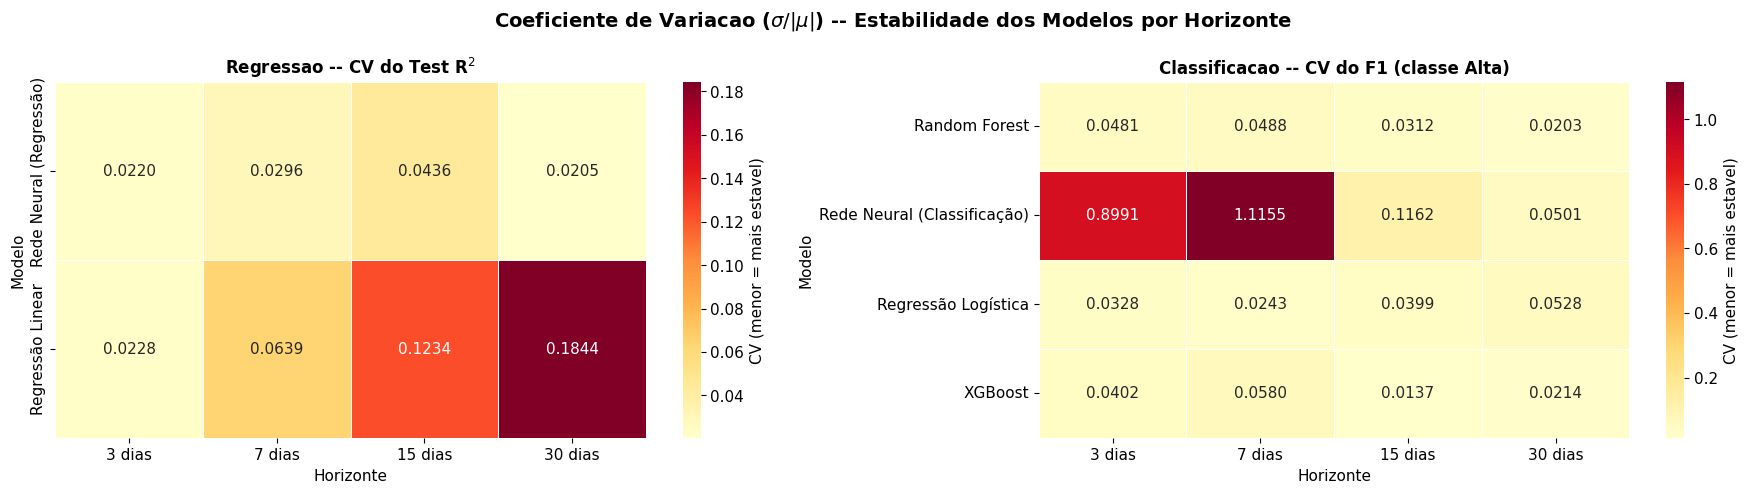


=== Coeficiente de Variacao - REGRESSAO (Test R^2) ===
                         3 dias  7 dias  15 dias  30 dias
modelo_nome                                              
Rede Neural (Regressão)  0.0220  0.0296   0.0436   0.0205
Regressão Linear         0.0228  0.0639   0.1234   0.1844

=== Coeficiente de Variacao - CLASSIFICACAO (F1 classe Alta) ===
                             3 dias  7 dias  15 dias  30 dias
modelo_nome                                                  
Random Forest                0.0481  0.0488   0.0312   0.0203
Rede Neural (Classificação)  0.8991  1.1155   0.1162   0.0501
Regressão Logística          0.0328  0.0243   0.0399   0.0528
XGBoost                      0.0402  0.0580   0.0137   0.0214


In [21]:
# ============================================================
# HEATMAP: Coeficiente de variacao por modelo x horizonte
# (regressao = Test_R2; classificacao = F1 da classe Alta)
# ============================================================

def matriz_coefvar(df, metrica):
    """Retorna DataFrame [modelos x horizontes] com CV = std / |mean|."""
    out = {}
    for h in HORIZONTES:
        df_h = df[df['Horizonte'] == h]
        if df_h.empty:
            continue
        agg = df_h.groupby('modelo_nome')[metrica].agg(['mean', 'std'])
        cv = agg['std'] / agg['mean'].abs()
        out[h] = cv
    return pd.DataFrame(out)


fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Coeficiente de Variacao ($\\sigma / |\\mu|$) -- Estabilidade dos Modelos por Horizonte',
             fontsize=14, fontweight='bold')

# --- Regressao (Test_R2) ---
ax = axes[0]
mat_reg = matriz_coefvar(df_regressao, 'Test_R2')
sns.heatmap(
    mat_reg, annot=True, fmt='.4f', cmap='YlOrRd',
    ax=ax, linewidths=0.5, cbar_kws={'label': 'CV (menor = mais estavel)'},
)
ax.set_title('Regressao -- CV do Test R$^2$', fontsize=12, fontweight='bold')
ax.set_xlabel('Horizonte')
ax.set_ylabel('Modelo')

# --- Classificacao (F1 Alta) ---
ax = axes[1]
mat_clf = matriz_coefvar(df_classificacao, 'Teste_F1_Classe_Alta')
sns.heatmap(
    mat_clf, annot=True, fmt='.4f', cmap='YlOrRd',
    ax=ax, linewidths=0.5, cbar_kws={'label': 'CV (menor = mais estavel)'},
)
ax.set_title('Classificacao -- CV do F1 (classe Alta)', fontsize=12, fontweight='bold')
ax.set_xlabel('Horizonte')
ax.set_ylabel('Modelo')

plt.tight_layout()
plt.savefig('heatmap_coefvar_modelos.png', bbox_inches='tight', dpi=150)
plt.show()

# Tabela imprimivel
print('\n=== Coeficiente de Variacao - REGRESSAO (Test R^2) ===')
print(mat_reg.round(4).to_string())
print('\n=== Coeficiente de Variacao - CLASSIFICACAO (F1 classe Alta) ===')
print(mat_clf.round(4).to_string())